# QAOA-vs-exact scaling experiment

How does QAOA (on the Aer statevector simulator) scale against the exact
classical baselines as the battery-scheduling QUBO grows? Because the
state-of-charge inequalities are encoded with bounded binary slack, the qubit
count grows as **m = 4T − 2** (6, 10, 14, 18, 22 for T = 2..6).

Results of `scripts/experiment_scaling.py` — one fixed configuration across the
whole sweep (`n_starts=5`, `shots=4096`, `maxiter=200`, seed 1234; 3 instance
seeds per T; reps ∈ {1,2,3}). Every configured run is reported: no seeds dropped,
no per-instance tuning. A **uniform-random-sampling baseline** (exact, from the
brute-force enumeration for T ≤ 5) is added post-hoc for honest comparison.

In [1]:
import sys
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
import experiment_scaling as exp

%matplotlib inline

rows = exp.load_results(Path.cwd().parent / "docs" / "results" / "qaoa_scaling.csv")
print(f"{len(rows)} runs loaded")

45 runs loaded


## Summary by (T, reps)

Aggregated over the 3 instance seeds. `obs_mass` is the observed optimal
probability mass (reported as `<1/4096` when no optimal bitstring appeared in
4096 shots — below the shot-noise floor). `ratio` is QAOA's optimal mass ÷
uniform sampling's; a leading `<` marks an **upper bound** (mass below floor).
`—` at T=6 because m=22 exceeds the enumeration cap, so there is no uniform
baseline (and DP is the sole ground truth).

In [2]:
floor = 1.0 / 4096
Ts = sorted({r['T'] for r in rows})
reps_vals = sorted({r['reps'] for r in rows})

print(f"{'T':>2} {'m':>3} {'reps':>4} {'exact':>6} {'obs_mass':>9} {'ratio':>8} {'unif_mass':>10} {'qaoa_s':>7} {'dp_s':>9}")
for T in Ts:
    for reps in reps_vals:
        g = [r for r in rows if r['T'] == T and r['reps'] == reps]
        exact = np.mean([r['exact_match'] for r in g])
        obs = np.mean([r['opt_prob_mass'] for r in g])
        obs_s = f'<{floor:.1e}' if obs == 0 else f'{obs:.4f}'
        um = g[0].get('uniform_opt_mass', float('nan'))
        if np.isnan(um):
            ratio_s, um_s = '\u2014', '\u2014'
        else:
            ratio = np.mean([r['mass_ratio'] for r in g])
            ub = any(r['mass_ratio_is_upper_bound'] for r in g)
            ratio_s = ('<' if ub else '') + f'{ratio:.2f}'
            um_s = f'{um:.4f}'
        qaoa_s = np.mean([r['qaoa_time_s'] for r in g])
        dp_s = np.mean([r['dp_time_s'] for r in g])
        print(f"{T:>2} {g[0]['m']:>3} {reps:>4} {exact:>6.2f} {obs_s:>9} {ratio_s:>8} {um_s:>10} {qaoa_s:>7.1f} {dp_s:>9.2e}")

 T   m reps  exact  obs_mass    ratio  unif_mass  qaoa_s      dp_s
 2   6    1   1.00    0.0323     2.07     0.0156     5.1  1.37e-04
 2   6    2   1.00    0.0007     0.04     0.0156     5.8  1.25e-04
 2   6    3   1.00    0.0268     1.71     0.0156     6.9  9.36e-05
 3  10    1   0.67    0.0021    <2.25     0.0010     7.0  1.01e-04
 3  10    2   0.67    0.0010    <1.08     0.0010     9.2  8.57e-05
 3  10    3   0.67    0.0002    <0.25     0.0010    10.2  9.02e-05
 4  14    1   0.33    0.0002    <5.33     0.0001    16.9  1.13e-04
 4  14    2   0.00  <2.4e-04    <4.00     0.0001    29.2  1.49e-04
 4  14    3   0.33    0.0001    <4.00     0.0001    33.3  1.55e-04
 5  18    1   0.00  <2.4e-04   <64.00     0.0000    32.9  1.37e-04
 5  18    2   0.00  <2.4e-04   <64.00     0.0000    59.1  1.63e-04
 5  18    3   0.00  <2.4e-04   <64.00     0.0000    95.5  1.74e-04
 6  22    1   0.00  <2.4e-04        —          —   684.2  2.43e-04
 6  22    2   0.00  <2.4e-04        —          —  1237.8  2.08

## Success rate vs T

Note: at **T=2 (64 states) and T=3 (1024 states)**, 4096 shots cover the entire
search space, so best-of-shots exact-match is trivially near 1.0 for QAOA *and*
for uniform sampling — **exact-match alone is uninformative there**. The mass
ratio below is the honest metric.

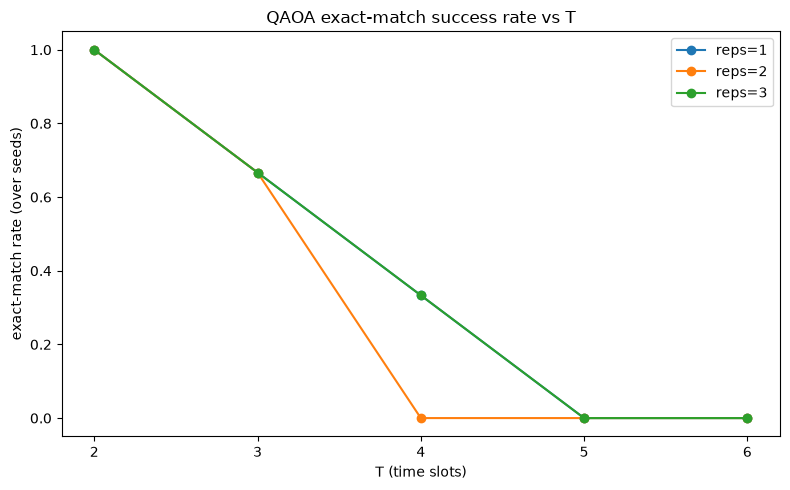

In [3]:
fig = exp.plot_success_rate(rows)

## Optimal probability mass vs T

The share of the final circuit's 4096 shots landing on an optimal bitstring — a
far harsher measure than best-of-shots exact-match. Values of 0 are below the
1/4096 shot-noise floor.

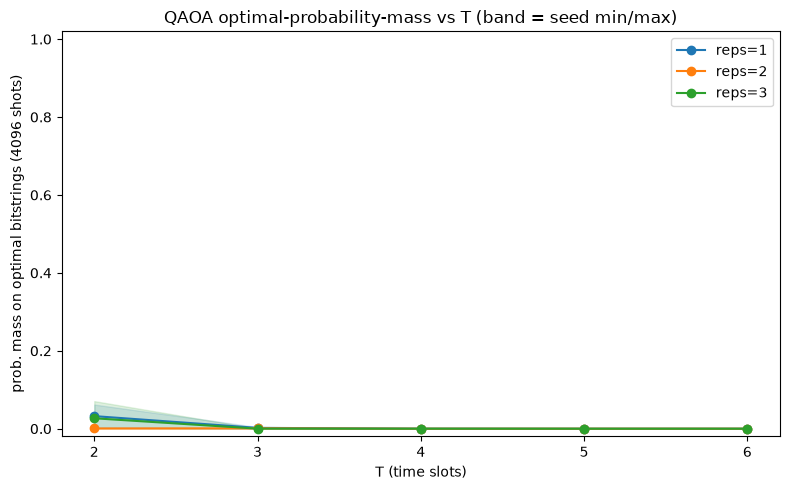

In [4]:
fig = exp.plot_optimal_mass(rows)

## QAOA vs uniform sampling: the mass ratio

QAOA's optimal mass divided by uniform sampling's exact optimal mass. Ratio > 1
means QAOA concentrates more probability on optima than random guessing; ▽
markers are upper bounds (observed mass below the 1/4096 floor).

**Reading the upper bounds carefully:** where points are ▽, a large ratio does
*not* prove QAOA beats uniform. It mainly reflects uniform's optimal mass (1/2^m)
collapsing *faster* than the shot floor, while QAOA's true mass is unmeasurable
(below 1/4096). So the rising ratio at T=5 is an artifact of the vanishing
denominator, not evidence of QAOA improving.

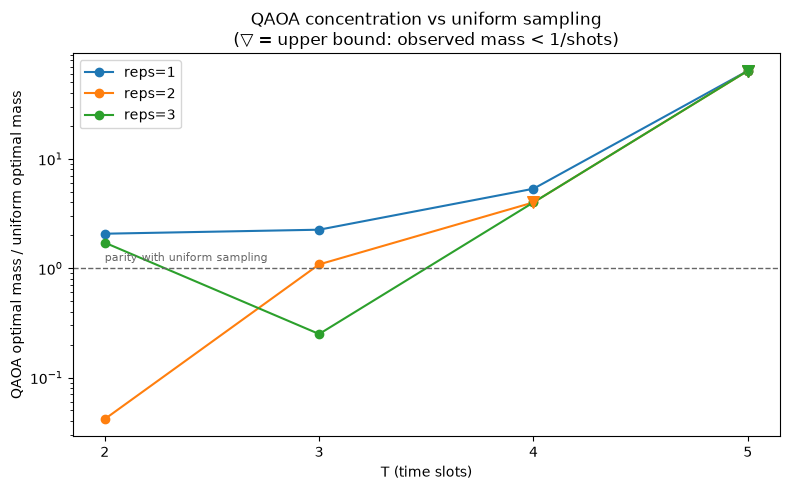

In [5]:
fig = exp.plot_mass_ratio(rows)

## Runtime and qubit count vs T

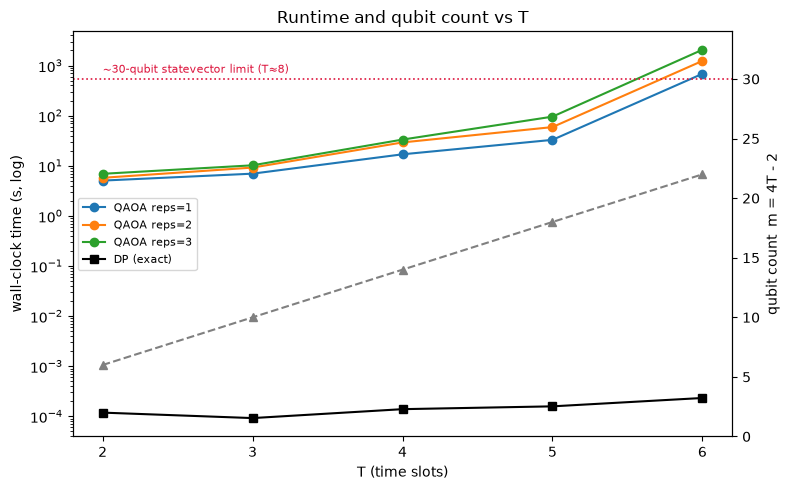

In [6]:
fig = exp.plot_runtime_qubits(rows)

## What was measured, and the honest conclusion

**Setup.** Synthetic battery-scheduling instances for T ∈ {2,3,4,5,6} (3 seeds
each), each built into a QUBO with the exact bounded-slack SoC encoding, so the
qubit count is **m = 4T − 2**. Ground truth is `dp_solve` for every instance and
`brute_force_solve` as an independent cross-check for T ≤ 5 (m ≤ 20). At **T = 6
(m = 22) brute force is over the enumeration cap, so DP alone is ground truth —
which is precisely why the polynomial DP baseline exists.**

**Baselines and metrics.** A uniform-random-sampling baseline is computed exactly
from the enumeration (T ≤ 5): the optimal probability mass of a single uniform
draw, and the expected best-of-4096-uniform-shots cost (via order statistics, not
Monte Carlo). QAOA is judged against it three ways: best-of-shots exact-match,
optimal probability mass, and the **mass ratio** QAOA_mass / uniform_mass.

**Trends.**
- *Exact-match is uninformative at small T.* At T=2 (64 states) and T=3 (1024),
  4096 shots cover the whole space, so both QAOA and uniform sampling essentially
  always contain the optimum — exact-match ≈ 1.0 says nothing. The **mass ratio**
  is the honest metric: it asks whether QAOA concentrates probability on optima
  better than random.
- *QAOA's edge is modest where measurable, then unmeasurable.* In the regime where
  both masses are above the shot floor (small T), QAOA places somewhat more mass
  on optima than uniform (ratio of order a few×) — but that is exactly the
  shot-covered regime. By T=5 QAOA's observed optimal mass falls below the 1/4096
  floor, so its mass ratio becomes only an **upper bound**; it looks large purely
  because uniform's mass (1/2^m) collapses faster, and it does **not** establish
  that QAOA beats random sampling there.
- *Low raw-sample feasibility is expected, not a bug.* The SoC/terminal penalties
  only *softly* shape the distribution, especially at low `reps`, so most
  individual samples are infeasible (feasibility ~1–3% at the larger T). We report
  the rate rather than tuning it away.
- *Runtime is the decisive story.* DP solves every instance in **microseconds**,
  flat in T. QAOA-on-simulator climbs steeply: a single T=6 (22-qubit) run takes
  10–28 minutes, because each optimizer step statevector-simulates a 2^22 ≈ 4M-
  amplitude circuit. The ~30-qubit statevector ceiling (≈ T=8) marks where this
  approach ends on a laptop.

**Conclusion.** For this problem the classical DP wins decisively: exact,
polynomial, microsecond-fast. QAOA-on-simulator is capped by slack-driven qubit
growth (m = 4T − 2) and by a landscape that places vanishing — eventually
sub-shot-noise — probability on the optimum as size grows; past the shot-covered
regime we cannot even confirm it concentrates probability better than uniform
sampling. That is not a failure of the harness; it *is* the result, and every run
that produced it is reported. The 10–28-minute T=6 runs, felt directly on a
laptop, are the exponential cost of classically simulating quantum circuits — the
same wall that makes real quantum hardware interesting: hardware would evaluate
the 22-qubit circuit natively instead of simulating 4M amplitudes. Whether QAOA
on hardware could beat DP here is a separate question this simulation cannot
answer; what it *can* say is that the exact-slack encoding's qubit growth makes
classical simulation the binding constraint long before any quantum advantage
could appear.